# <font style="color:black">Aprimoramento Básico de Imagens Usando Operações Matemáticas</font>
As técnicas de processamento de imagens utilizam operações matemáticas para alcançar diferentes resultados. Na maioria das vezes, obtemos uma versão aprimorada da imagem usando algumas operações básicas. Vamos analisar algumas das operações fundamentais frequentemente usadas em fluxos de trabalho de visão computacional. Neste notebook, abordaremos:

* Operações aritméticas como adição e multiplicação
* Limiarização e mascaramento
* Operações bit a bit como OR, AND e XOR

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image 
%matplotlib inline
from IPython.display import Image


### <font color="green">Imagem original</font>

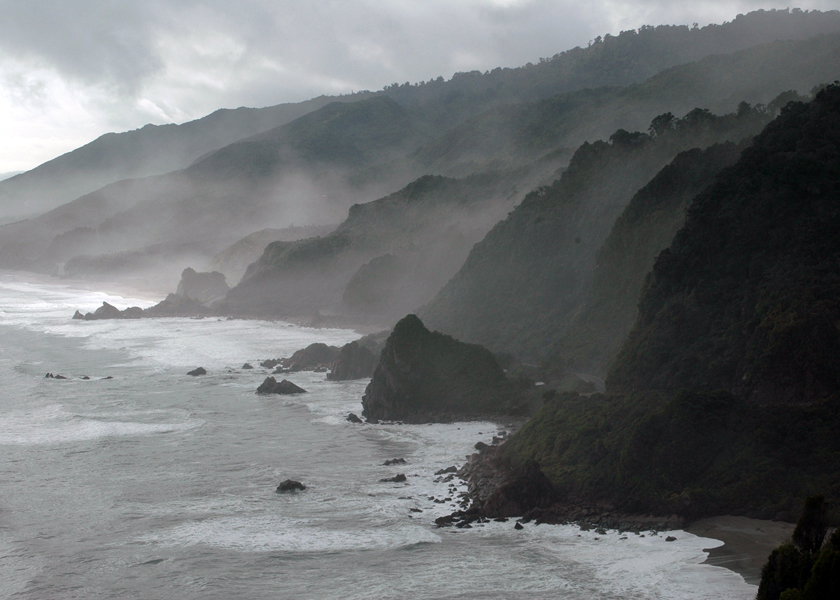

In [2]:
img_bgr = cv2.imread("New_Zealand_Coast.jpg",cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display 18x18 pixel image.
Image(filename='New_Zealand_Coast.jpg')

## Adição ou Brilho
A primeira operação que discutiremos é a simples adição de imagens. Isso resulta no aumento ou diminuição do brilho da imagem, já que, em última análise, estamos aumentando ou diminuindo os valores de intensidade de cada pixel na mesma proporção. Portanto, isso resultará em um aumento/diminuição global do brilho.

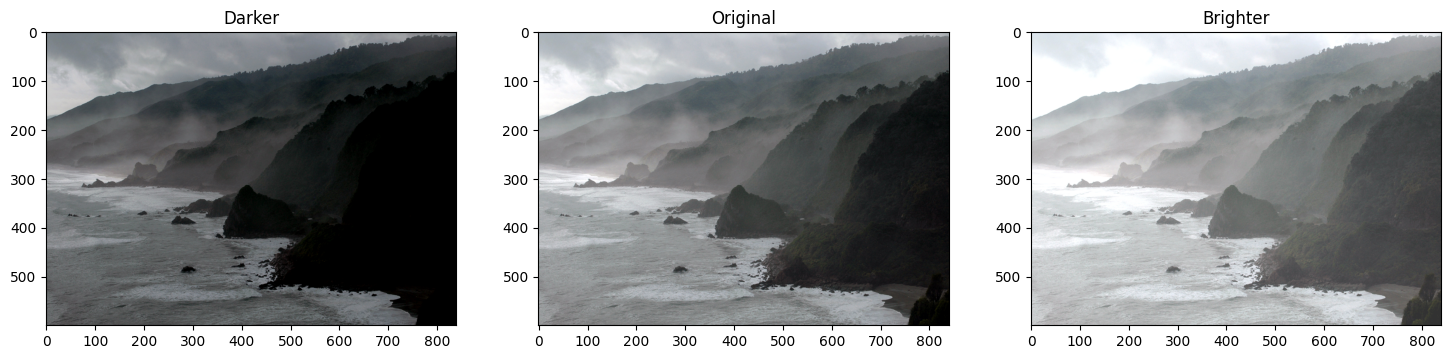

In [3]:
matrix = np.ones(img_rgb.shape, dtype = "uint8") * 50

img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker   = cv2.subtract(img_rgb, matrix)

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Brighter");

## Multiplicação ou Contraste
Assim como a adição pode resultar em alteração de brilho, a multiplicação pode ser usada para melhorar o contraste da imagem.

O contraste é a diferença nos valores de intensidade dos pixels de uma imagem. Multiplicar os valores de intensidade por uma constante pode aumentar ou diminuir a diferença (se o fator de multiplicação for < 1).

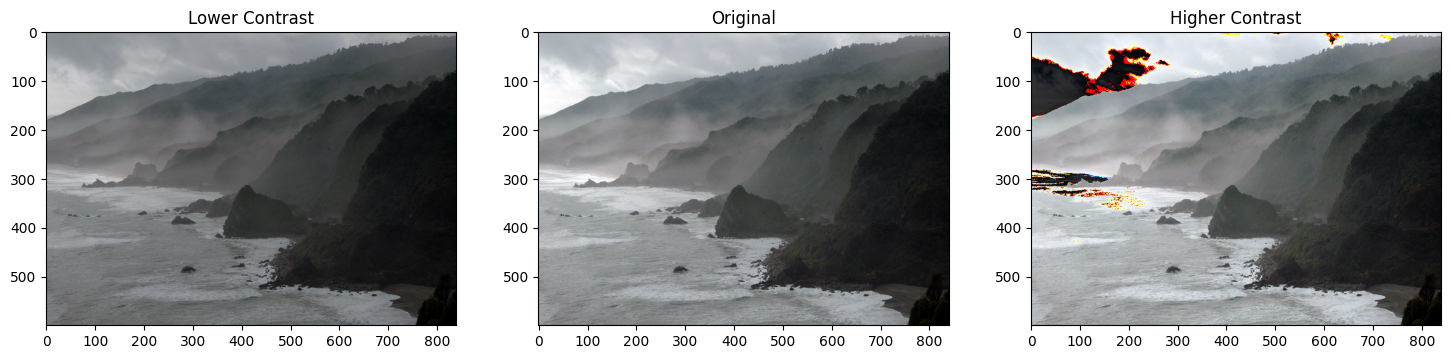

In [9]:
matrix1 = np.ones(img_rgb.shape) * .8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker   = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Higher Contrast");

### <font color="green">O que aconteceu?</font>
Você consegue ver as cores estranhas em algumas áreas da imagem após a multiplicação?

O problema é que, após a multiplicação, os valores que já eram altos ficam maiores que 255. Portanto, ocorre um estouro de capacidade. Como podemos resolver isso?

### <font color="green">Lidando com estouro de buffer usando np.clip</font>

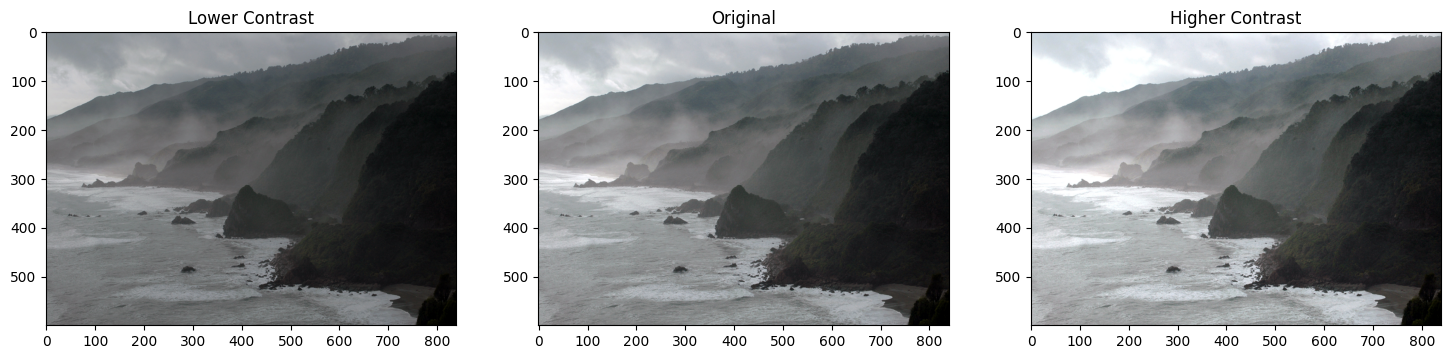

In [11]:
matrix1 = np.ones(img_rgb.shape) * .8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_lower   = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_higher  = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2),0,255))

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower);  plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("Higher Contrast");

## Limiarização de Imagens
Imagens binárias têm muitas aplicações em Processamento de Imagens. Uma das mais comuns é a criação de máscaras. Máscaras de imagem permitem processar partes específicas de uma imagem, mantendo as demais intactas. A limiarização de imagens é usada para criar imagens binárias a partir de imagens em tons de cinza. Você pode usar diferentes limiares para criar diferentes imagens binárias a partir da mesma imagem original.

### <font color="green">Sintaxe da Função</font>

``` python
retval, dst = cv2.threshold( src, thresh, maxval, type[, dst] )
```

`dst`: O array de saída com o mesmo tamanho, tipo e número de canais que `src`.

A função possui **4 argumentos obrigatórios**:

1. `src`: array de entrada (multicanal, ponto flutuante de 8 ou 32 bits).

2. `thresh`: valor do limiar.

3. `maxval`: valor máximo a ser usado com os tipos de limiarização THRESH_BINARY e THRESH_BINARY_INV.
4. `type`: tipo de limiarização (consulte ThresholdTypes).

### <font color="green">Sintaxe da Função</font>

``` python
dst = cv.adaptiveThreshold( src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst] )
```

`dst` Imagem de destino do mesmo tamanho e tipo que src.

A função possui **6 argumentos obrigatórios**:
1. `src`: Imagem de origem de 8 bits de canal único.

2. `maxValue`: Valor diferente de zero atribuído aos pixels para os quais a condição é satisfeita.
3. `adaptiveMethod`: Algoritmo de limiarização adaptativa a ser usado, consulte AdaptiveThresholdTypes. A função BORDER_REPLICATE | BORDER_ISOLATED é usada para processar limites.
4. `thresholdType`: Tipo de limiar que deve ser THRESH_BINARY ou THRESH_BINARY_INV, consulte ThresholdTypes.
5. `blockSize`: Tamanho de uma vizinhança de pixels usada para calcular um valor de limiar para o pixel: 3, 5, 7 e assim por diante.
6. `C`: Constante subtraída da média ou média ponderada (veja os detalhes abaixo). Normalmente, é positiva, mas também pode ser zero ou negativa.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

https://docs.opencv.org/4.5.1/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57
https://docs.opencv.org/4.5.1/d7/d4d/tutorial_py_thresholding.html

(572, 800)


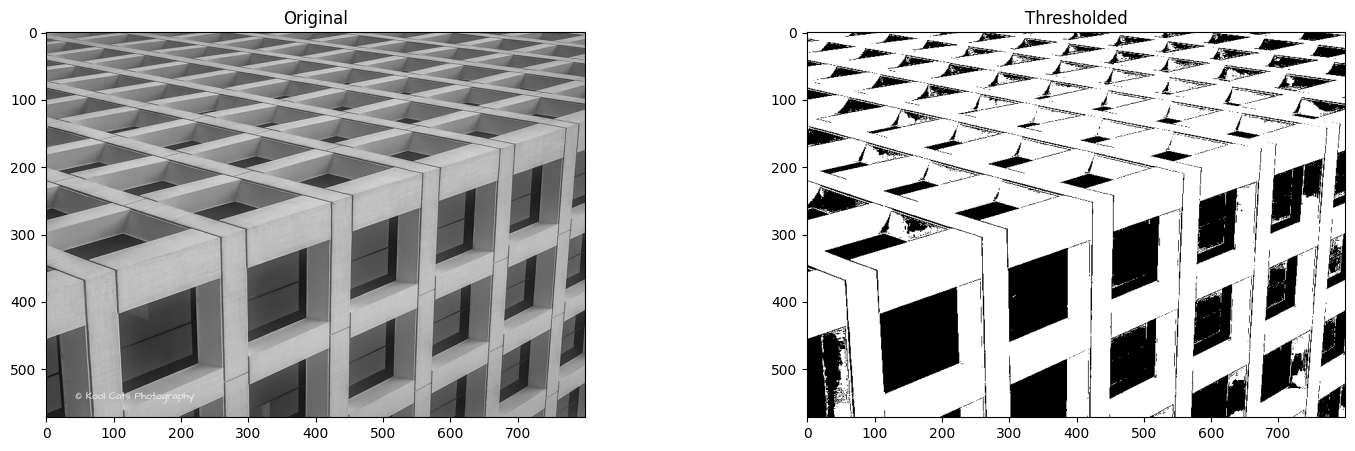

In [12]:
img_read = cv2.imread("building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(121); plt.imshow(img_read, cmap="gray");         plt.title("Original");
plt.subplot(122); plt.imshow(img_thresh, cmap="gray");       plt.title("Thresholded");

print(img_thresh.shape)

## Aplicação: Leitor de Partituras
Suponha que você queira criar um aplicativo capaz de ler (decodificar) partituras. Isso é semelhante ao
Reconhecimento Óptico de Caracteres (OCR) para documentos de texto, cujo objetivo é reconhecer caracteres de texto. Em ambas as aplicações, uma das primeiras etapas no fluxo de processamento é isolar as informações importantes na imagem de um documento (separando-as do fundo). Essa tarefa pode ser realizada com técnicas de limiarização.
Vejamos um exemplo.

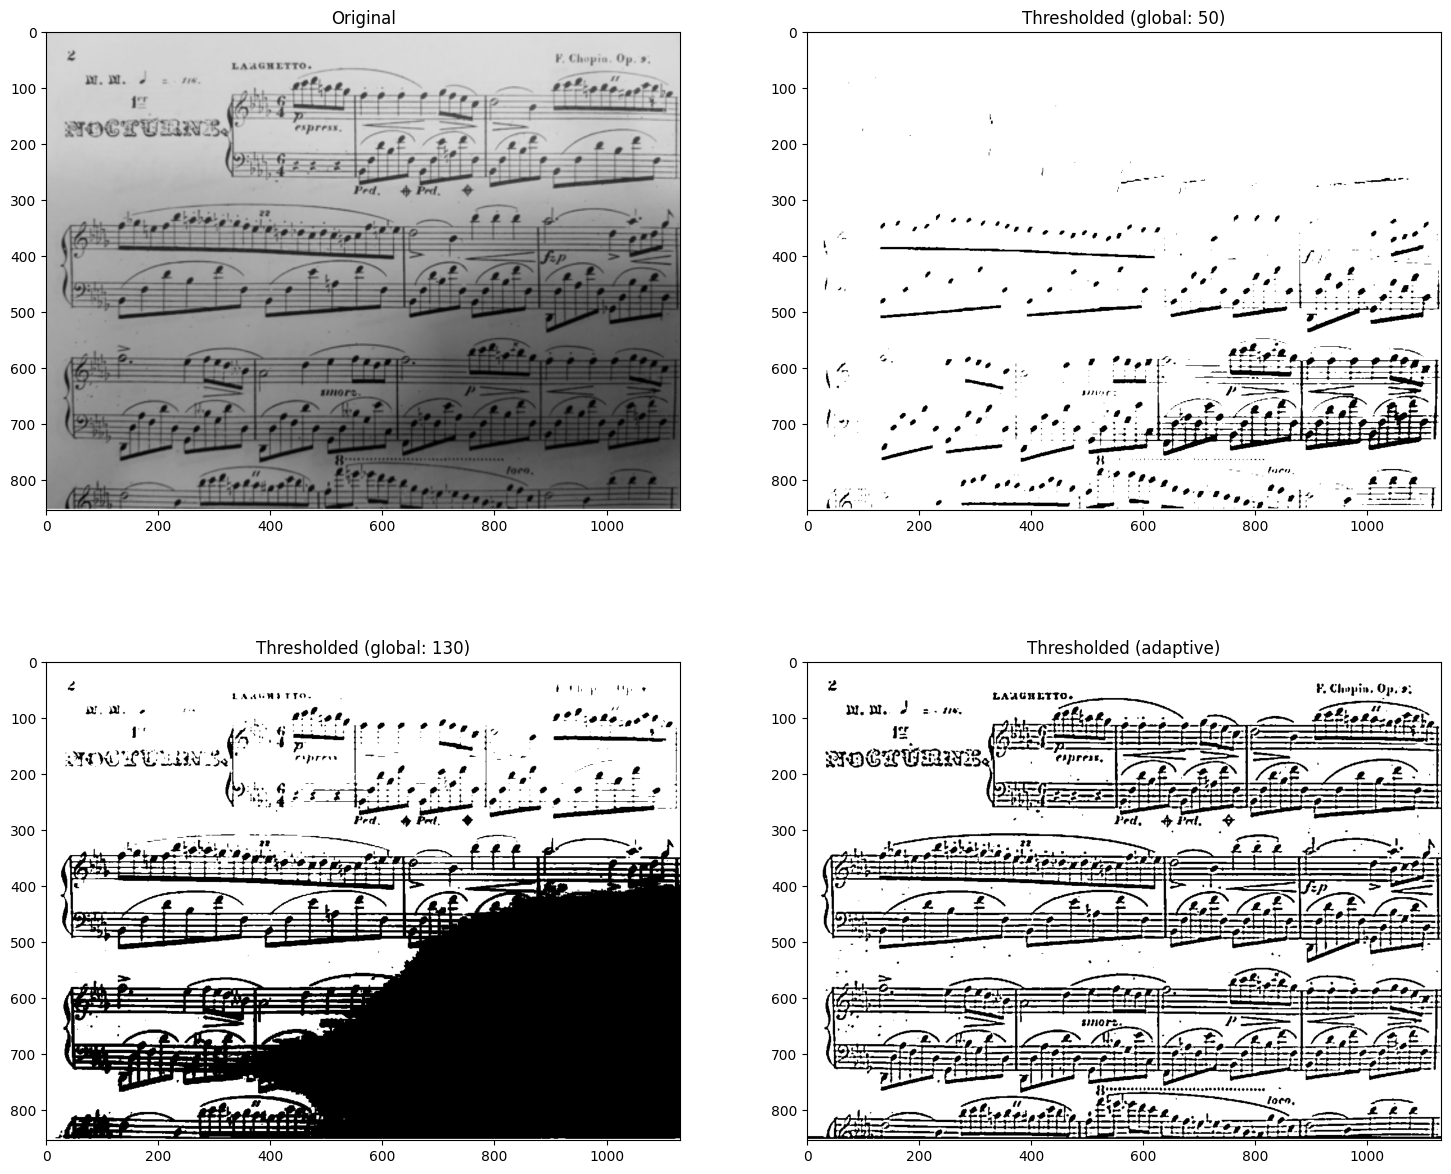

In [13]:
# Read the original image
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

# Perform global thresholding
retval, img_thresh_gbl_1 = cv2.threshold(img_read,50, 255, cv2.THRESH_BINARY)

# Perform global thresholding
retval, img_thresh_gbl_2 = cv2.threshold(img_read,130, 255, cv2.THRESH_BINARY)

# Perform adaptive thresholding
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

# Show the images
plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

## Operações Bit a Bit

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>

Exemplo de API para `cv2.bitwise_and()`. Outras incluem: `cv2.bitwise_or()`, `cv2.bitwise_xor()`, `cv2.bitwise_not()`

``` python
dst = cv2.bitwise_and( src1, src2[, dst[, mask]] )
```

`dst`: Array de saída com o mesmo tamanho e tipo dos arrays de entrada.

A função possui **2 argumentos obrigatórios**:

1. `src1`: primeiro array de entrada ou um escalar.

2. `src2`: segundo array de entrada ou um escalar.

Um argumento opcional importante é:

1. `mask`: máscara de operação opcional, matriz de canal único de 8 bits, que especifica os elementos da matriz de saída a serem alterados.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

https://docs.opencv.org/4.5.1/d0/d86/tutorial_py_image_arithmetics.html
https://docs.opencv.org/4.5.0/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14

(200, 499)


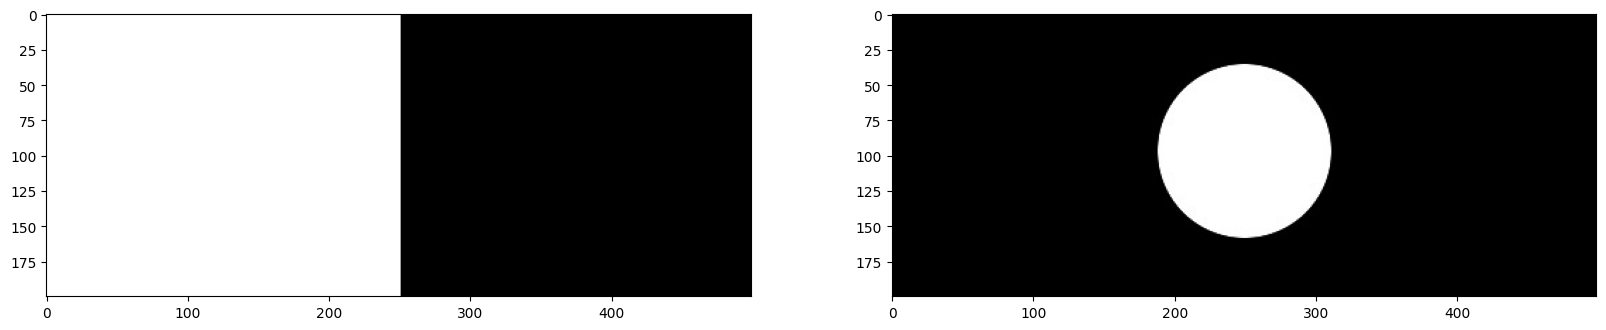

In [14]:
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)

img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20,5])
plt.subplot(121);plt.imshow(img_rec,cmap='gray')
plt.subplot(122);plt.imshow(img_cir,cmap='gray')
print(img_rec.shape)

### <font color="green">Operador AND bit a bit</font>

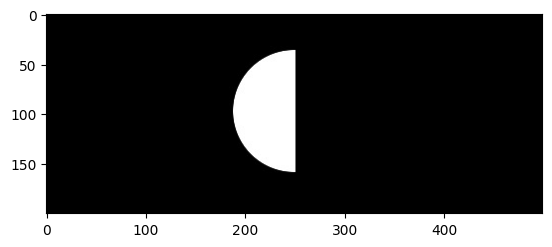

In [15]:
result = cv2.bitwise_and(img_rec, img_cir, mask = None)
plt.imshow(result,cmap='gray')

### <font color="green">Operador OR bit a bit</font>

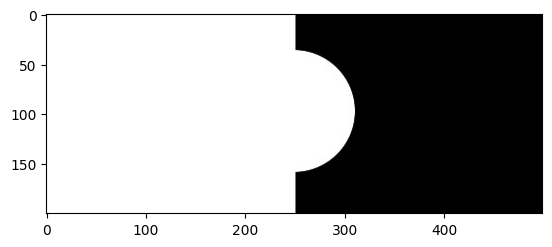

In [16]:
result = cv2.bitwise_or(img_rec, img_cir, mask = None)
plt.imshow(result,cmap='gray')

### <font color="green">Operador XOR bit a bit</font>

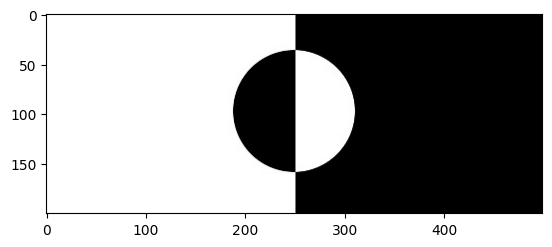

In [17]:
result = cv2.bitwise_xor(img_rec, img_cir, mask = None)
plt.imshow(result,cmap='gray')

## Aplicação: Manipulação de Logotipo

Nesta seção, mostraremos como preencher as letras brancas do logotipo da Coca-Cola abaixo com uma imagem de fundo.

In [18]:
Image(filename='Logo_Manipulation.png')

FileNotFoundError: [Errno 2] No such file or directory: 'Logo_Manipulation.png'

### <font color="green">Leia a imagem em primeiro plano</font>

(700, 700, 3)


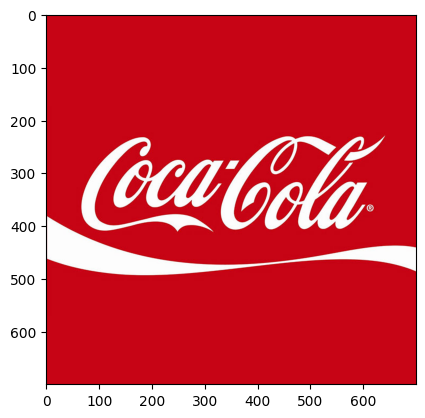

In [19]:
img_bgr = cv2.imread("coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
print(img_rgb.shape)
logo_w = img_rgb.shape[0]
logo_h = img_rgb.shape[1]

### <font color="green">Leia a imagem de fundo</font>

(700, 700, 3)


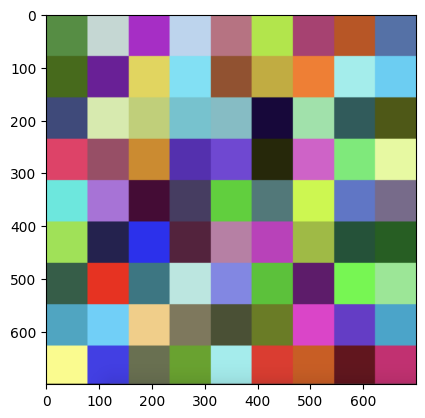

In [20]:
# Read in image of color cheackerboad background
img_background_bgr = cv2.imread("checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)

# Set desired width (logo_w) and maintain image aspect ratio
aspect_ratio = logo_w / img_background_rgb.shape[1]
dim = (logo_w, int(img_background_rgb.shape[0] * aspect_ratio))

# Resize background image to sae size as logo image
img_background_rgb = cv2.resize(img_background_rgb, dim, interpolation=cv2.INTER_AREA)

plt.imshow(img_background_rgb) 
print(img_background_rgb.shape)

### <font color="green">Criar máscara para a imagem original</font>

(700, 700)


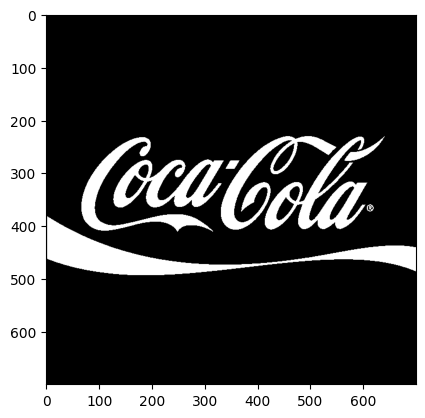

In [21]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply global thresholding to creat a binary mask of the logo
retval, img_mask = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)

plt.imshow(img_mask,cmap="gray")
print(img_mask.shape)

### <font color="green">Inverter a máscara</font>

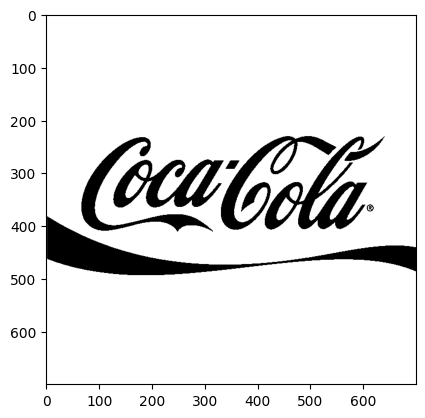

In [22]:
# Create an inverse mask
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv,cmap="gray")

### <font color="green">Aplicar fundo na máscara</font>

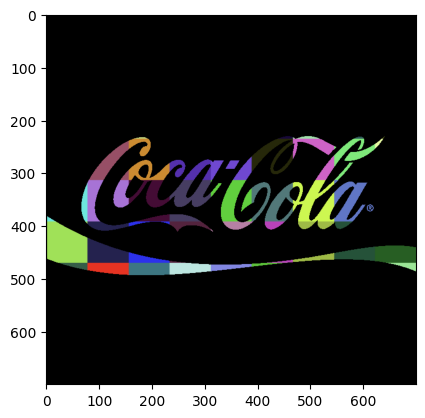

In [23]:
# Create colorful background "behind" the logo lettering
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background)

### <font color="green">Isolar o primeiro plano da imagem</font>

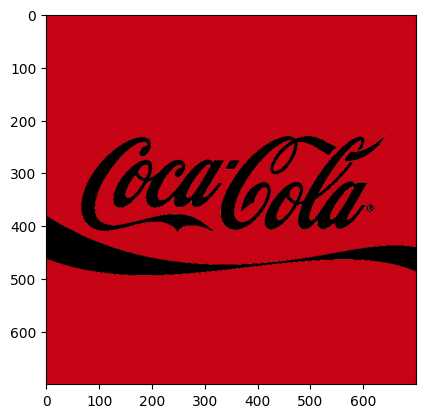

In [24]:
# Isolate foreground (red from original image) using the inverse mask
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground)

### <font color="green">Resultado: Mesclar primeiro plano e plano de fundo</font>

True

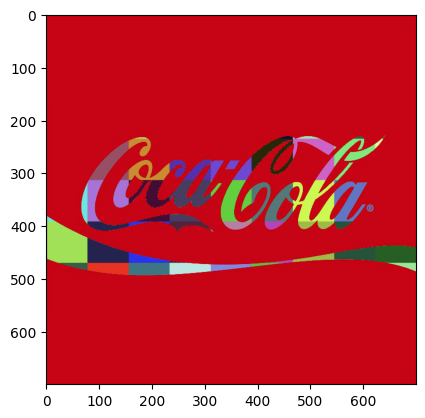

In [25]:
# Add the two previous results obtain the final result
result = cv2.add(img_background,img_foreground)
plt.imshow(result)
cv2.imwrite("logo_final.png", result[:,:,::-1])